# Exploratory Data Analysis Project
This EDA explores restaurant server tips

## Dataset Information
"Total bill (cost of the meal), including tax, in US dollars, Tip (gratuity) in US dollars, Sex of person paying for the meal, Smoker in party?, Day of Week, Meal Time" [Description Source](https://www.kaggle.com/datasets/ranjeetjain3/seaborn-tips-dataset)
### It's important to note that this dataset was collected in the 1990s, analysis was performed for the raw data, and the data adjusted for inflation by a factor of 2.55


# Project Setup
Analysis and Graphs were primarily created with Seaborn

In [ ]:
import logging  # for type hinting only
from pathlib import Path
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
from matplotlib.axes import Axes
import pandas as pd
import seaborn as sns

# A figure can contain multiple axes (plots)
# from matplotlib.figure import Figure

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("EDA-NBA", level="DEBUG")
log_header(LOG, "EDA-NBA")

# CUSTOM: Data set name
# Available seaborn datasets: ['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones',
#'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']

# project_root = Path.cwd().parents[1]

SCALE = False
if SCALE:
    LOG.info("Scaling is ON. Adjusting for inflation.")
    SCALING_FACTOR = 2.55  # 2024-06-01 inflation factor for US dollars, to adjust for inflation since the dataset was collected in 1990s src (google AI)
    output_dir = Path("../docs") / "images" / "inflation_considered"

else:
    LOG.info("Scaling is OFF. Not adjusting for inflation.")
    output_dir = Path("../docs") / "images" / "inflation_NOT_considered"
    SCALING_FACTOR = 1.0  # pyright: ignore[reportConstantRedefinition]

OUTPUT_DIR: Final[Path] = output_dir  # type: ignore
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_NAME: Final[str] = "tips"

#
LOG.info("Chose dataset: %s", DATASET_NAME)
# === Section 1d. Pandas Configuration for Display ===

# Pandas display configuration (helps in notebooks)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

LOG.info("Imports complete.")

2026-06-07 19:06:47 | INFO | EDA-NBA | === RUN START ===
2026-06-07 19:06:47 | INFO | EDA-NBA | project=EDA-NBA
2026-06-07 19:06:47 | INFO | EDA-NBA | repo_dir=datafun-04-notebooks
2026-06-07 19:06:47 | INFO | EDA-NBA | python=3.14.0
2026-06-07 19:06:47 | INFO | EDA-NBA | os=Windows 11
2026-06-07 19:06:47 | INFO | EDA-NBA | shell=powershell
2026-06-07 19:06:47 | INFO | EDA-NBA | cwd=notebooks
2026-06-07 19:06:47 | INFO | EDA-NBA | github_actions=False
2026-06-07 19:06:47 | INFO | EDA-NBA | Scaling is OFF. Not adjusting for inflation.
2026-06-07 19:06:47 | INFO | EDA-NBA | Chose dataset: tips
2026-06-07 19:06:47 | INFO | EDA-NBA | Imports complete.


# Inspect Data

In [17]:
LOG.info("Quickly Summarize Dataset To Confirm Suitability")

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)

LOG.info(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
LOG.info("Adjusting for inflation using factor: %s", SCALING_FACTOR)
df["total_bill"] *= SCALING_FACTOR
df["tip"] *= SCALING_FACTOR

LOG.info("Previewing first few rows of the dataset")
display(df.head())

LOG.info("Column names")
print(list(df.columns))

LOG.info("Data types and non-null counts")
df.info()

display(df.describe())

2026-06-07 19:06:47 | INFO | EDA-NBA | Quickly Summarize Dataset To Confirm Suitability
2026-06-07 19:06:47 | INFO | EDA-NBA | Loading dataset: tips
2026-06-07 19:06:47 | INFO | EDA-NBA | Loaded: 244 rows, 7 columns
2026-06-07 19:06:47 | INFO | EDA-NBA | Adjusting for inflation using factor: 1.0
2026-06-07 19:06:47 | INFO | EDA-NBA | Previewing first few rows of the dataset


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


2026-06-07 19:06:47 | INFO | EDA-NBA | Column names
2026-06-07 19:06:47 | INFO | EDA-NBA | Data types and non-null counts


['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [18]:
shape: tuple[int, int] = df.shape
num_rows, num_cols = shape
LOG.info(f"Dataset shape: {num_rows} rows, {num_cols} columns")

2026-06-07 19:06:47 | INFO | EDA-NBA | Dataset shape: 244 rows, 7 columns


# Create Data Dictionary and confirm Data Quality

In [19]:
LOG.info("Building starter data dictionary")

data_dictionary = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
    }
)

LOG.debug(f"\n{data_dictionary}")

2026-06-07 19:06:47 | INFO | EDA-NBA | Building starter data dictionary
2026-06-07 19:06:47 | DEBUG | EDA-NBA | 
       column     dtype  missing_count  missing_pct
0  total_bill   float64              0          0.0
1         tip   float64              0          0.0
2         sex  category              0          0.0
3      smoker  category              0          0.0
4         day  category              0          0.0
5        time  category              0          0.0
6        size     int64              0          0.0


### None of the data is missing. Check for duplicates.

In [20]:
dup_count = int(df.duplicated().sum())
LOG.info(f"Duplicate rows detected: {dup_count}")

LOG.info("Call describe() for numeric columns")
LOG.debug(f"\n{df.select_dtypes(include='number').describe()}\n")

2026-06-07 19:06:47 | INFO | EDA-NBA | Duplicate rows detected: 1
2026-06-07 19:06:47 | INFO | EDA-NBA | Call describe() for numeric columns
2026-06-07 19:06:47 | DEBUG | EDA-NBA | 
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000



# Clean Data

In [21]:
df_clean: pd.DataFrame = df.drop_duplicates().copy()
LOG.info(
    f"After dropping duplicates: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns"
)
LOG.info(f"Duplicate rows dropped: {dup_count}")

2026-06-07 19:06:47 | INFO | EDA-NBA | After dropping duplicates: 243 rows, 7 columns
2026-06-07 19:06:47 | INFO | EDA-NBA | Duplicate rows dropped: 1


# Add New Columns of Interest

In [22]:
# Add percent_tips = tip / total_bill * 100 to get percentage
df_clean["percent_tips"] = (df_clean["tip"] / df_clean["total_bill"]) * 100.0
LOG.info("Added new column: percent_tips = tip / total_bill * 100")
# Add total_cost = total_bill + tip to get total cost of the meal including tip
df_clean["total_cost"] = df_clean["total_bill"] + df_clean["tip"]
LOG.info("Added new column: total_cost = total_bill + tip")
# Add total_cost_per_person = total_cost / size to get cost per person
df_clean["total_cost_per_person"] = df_clean["total_cost"] / df_clean["size"]
LOG.info("Added new column: total_cost_per_person = total_cost / size")
display(df_clean.head())

2026-06-07 19:06:47 | INFO | EDA-NBA | Added new column: percent_tips = tip / total_bill * 100
2026-06-07 19:06:47 | INFO | EDA-NBA | Added new column: total_cost = total_bill + tip
2026-06-07 19:06:47 | INFO | EDA-NBA | Added new column: total_cost_per_person = total_cost / size


,total_bill,tip,sex,smoker,day,time,size,percent_tips,total_cost,total_cost_per_person
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,18.00,9.000
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,12.00,4.000
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,24.51,8.170
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,26.99,13.495
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,28.20,7.050


# Descriptive Statistics For numeric values

In [23]:
LOG.info("Computing overall descriptive statistics")
stats_overall = df_clean.select_dtypes(include='number').describe().T
LOG.info(f"Overall descriptive statistics:\n{stats_overall}")

grouped = df_clean.groupby(df_clean.select_dtypes(include='category').columns.tolist())

df_stats_by_group: pd.DataFrame = grouped.agg(["count", "mean", "std", "min", "max"])

display(df_stats_by_group)

2026-06-07 19:06:47 | INFO | EDA-NBA | Computing overall descriptive statistics
2026-06-07 19:06:47 | INFO | EDA-NBA | Overall descriptive statistics:
                       count       mean       std       min        25%        50%        75%        max
total_bill             243.0  19.813868  8.910071  3.070000  13.380000  17.810000  24.175000  50.810000
tip                    243.0   3.002387  1.385002  1.000000   2.000000   2.920000   3.575000  10.000000
size                   243.0   2.572016  0.952356  1.000000   2.000000   2.000000   3.000000   6.000000
percent_tips           243.0  16.083121  6.119662  3.563814  12.883281  15.521855  19.174638  71.034483
total_cost             243.0  22.816255  9.897837  4.070000  15.640000  20.620000  27.785000  60.810000
total_cost_per_person  243.0   9.107580  3.210674  3.375000   6.746667   8.465000  10.720833  21.775000


total_bill                                       tip                                   size  \
                               count       mean        std    min    max count      mean       std   min    max count   
sex    smoker day  time                                                                                                 
Male   Yes    Thur Lunch          10  19.171000   6.757421  10.34  32.68    10  3.058000  1.111573  2.00   5.00    10   
              Fri  Lunch           3  11.386667   2.510963   8.58  13.42     3  1.900000  0.310483  1.58   2.20     3   
                   Dinner          5  25.892000  10.383290  12.03  40.17     5  3.246000  1.218639  1.50   4.73     5   
              Sat  Dinner         27  21.837778   9.988045   7.74  50.81    27  2.879259  1.744338  1.00  10.00    27   
              Sun  Dinner         15  26.141333  10.693824   7.25  45.35    15  3.521333  1.417432  1.50   6.50    15   
       No     Thur Lunch          20  18.486500   8.739134   7.51  41.19    20  2.941500  1.485623  1.44   6.70    20   
              Fri  Dinner          2  17.475000   7.092281  12.46  22.49     2  2.500000  1.414214  1.50   3.50     2   
              Sat  Dinner         32  19.929063   9.779061   9.55  48.33    32  3.256563  1.839749  1.25   9.00    32   
              Sun  Dinner         43  20.403256   8.140559   8.77  48.17    43  3.115349  1.216401  1.32   6.00    43   
Female Yes    Thur Lunch           6  20.255000  11.496491  12.74  43.11     6  3.155000  1.229223  2.00   5.00     6   
              Fri  Lunch           3  13.260000   3.093105  10.09  16.27     3  2.660000  0.752861  2.00   3.48     3   
                   Dinner          4  12.200000   4.810121   5.75  16.32     4  2.700000  1.363818  1.00   4.30     4   
              Sat  Dinner         15  20.266667  10.485703   3.07  44.30    15  2.868667  1.461378  1.00   6.50    15   
              Sun  Dinner          4  16.540000   4.854764   9.60  20.90     4  3.500000  0.408248  3.00   4.00     4   
       No     Thur Lunch          24  15.899167   6.904808   8.35  34.83    24  2.437083  1.095542  1.25   5.17    24   
                   Dinner          1  18.780000        NaN  18.78  18.78     1  3.000000       NaN  3.00   3.00     1   
              Fri  Lunch           1  15.980000        NaN  15.98  15.98     1  3.000000       NaN  3.00   3.00     1   
                   Dinner          1  22.750000        NaN  22.75  22.75     1  3.250000       NaN  3.25   3.25     1   
              Sat  Dinner         13  19.003846   6.730219   7.25  35.83    13  2.724615  0.961904  1.00   4.67    13   
              Sun  Dinner         14  20.824286   8.396159  10.29  35.26    14  3.329286  1.282356  1.01   5.20    14   

                                                      percent_tips                                              \
                               mean       std min max        count       mean        std        min        max   
sex    smoker day  time                                                                                          
Male   Yes    Thur Lunch   2.300000  0.674949   2   4           10  16.441676   4.576440   9.001406  24.125452   
              Fri  Lunch   1.666667  0.577350   1   2            3  17.414400   5.334460  11.773472  22.377622   
                   Dinner  2.400000  0.894427   2   4            5  12.708199   1.785405  10.355540  14.662757   
              Sat  Dinner  2.629630  0.926040   2   5           27  13.906681   5.145495   3.563814  20.557682   
              Sun  Dinner  2.600000  0.985611   2   5           15  17.396381  16.293658   6.565988  71.034483   
       No     Thur Lunch   2.500000  1.147079   2   6           20  16.570635   4.709744   7.861635  26.631158   
              Fri  Dinner  2.000000  0.000000   2   2            2  13.800498   2.491808  12.038523  15.562472   
              Sat  Dinner  2.656250  0.787375   2   4           32  16.213217   4.063484   9.820426  2

# Simple Numeric Correlations

In [24]:
LOG.info("Computing correlation matrix for numeric columns")

# Select only numeric columns
df_clean_numeric_cols: pd.DataFrame = df_clean.select_dtypes(include="number")

# calculate the correlation matrix using the df corr() method
correlation_matrix = df_clean_numeric_cols.corr()

LOG.info("\nCorrelation matrix:")
LOG.debug(f"\n{correlation_matrix}")

2026-06-07 19:06:47 | INFO | EDA-NBA | Computing correlation matrix for numeric columns
2026-06-07 19:06:47 | INFO | EDA-NBA | 
Correlation matrix:
2026-06-07 19:06:47 | DEBUG | EDA-NBA | 
                       total_bill       tip      size  percent_tips  total_cost  total_cost_per_person
total_bill               1.000000  0.674998  0.597589     -0.339400    0.994656               0.625110
tip                      0.674998  1.000000  0.488400      0.342408    0.747565               0.418913
size                     0.597589  0.488400  1.000000     -0.143252    0.606294              -0.199857
percent_tips            -0.339400  0.342408 -0.143252      1.000000   -0.257616              -0.205146
total_cost               0.994656  0.747565  0.606294     -0.257616    1.000000               0.621345
total_cost_per_person    0.625110  0.418913 -0.199857     -0.205146    0.621345               1.000000


# Visualizations

2026-06-07 19:06:47 | INFO | EDA-NBA | ---------Visualize Correlation Matrix as a Heatmap---------------


2026-06-07 19:06:48 | INFO | EDA-NBA | Saved correlation heatmap to: ..\docs\images\inflation_NOT_considered\heatmap.png


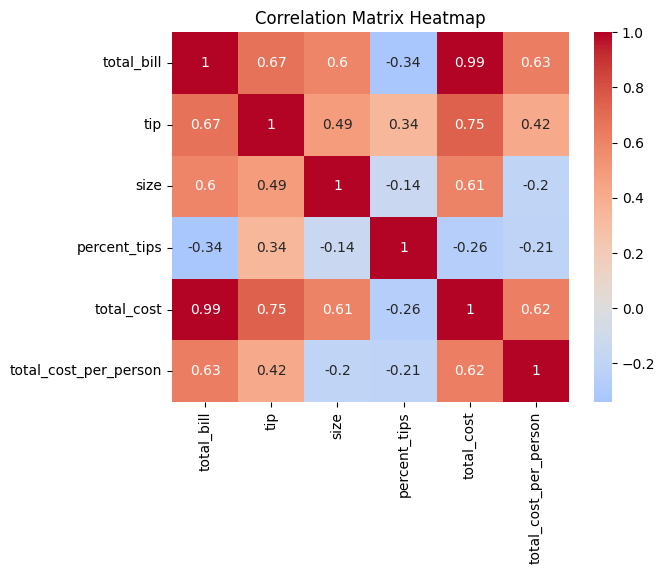

In [25]:
from matplotlib import pyplot as plt

LOG.info("---------Visualize Correlation Matrix as a Heatmap---------------")

# Set annotations to True to show correlation values
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",  # try coolwarm, viridis, plasma, or other colormaps
    center=0,
)
plt.title("Correlation Matrix Heatmap")
heatmap_path = OUTPUT_DIR / "heatmap.png"
plt.savefig(heatmap_path)
LOG.info(f"Saved correlation heatmap to: {heatmap_path}")
plt.show()

2026-06-07 19:06:48 | INFO | EDA-NBA | ---- Creating Scatter Plot to see Relationships ------
2026-06-07 19:06:48 | INFO | EDA-NBA | ----   Use clean dataframe ---------------------------
2026-06-07 19:06:48 | INFO | EDA-NBA | ----   Set the hue (color mapping) to the group column --


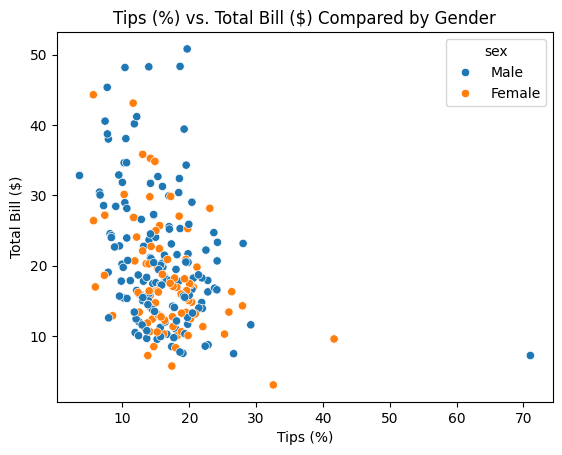

In [26]:
# Section 8 Python cell - use "Run All" so prior cells are executed first.

LOG.info("---- Creating Scatter Plot to see Relationships ------")
LOG.info("----   Use clean dataframe ---------------------------")
LOG.info("----   Set the hue (color mapping) to the group column --")

# Scatter plot to see relationship
scatter_plt: Axes = sns.scatterplot(
    data=df_clean, x="percent_tips", y="total_bill", hue="sex"
)
# day wasn't interesting so change to
# Set axis labels using the Matplotlib Axes methods set_xlabel() and set_ylabel()
scatter_plt.set_xlabel("Tips (%)")
scatter_plt.set_ylabel("Total Bill ($)")

# Set the title using the Matplotlib Axes set_title() method
scatter_plt.set_title("Tips (%) vs. Total Bill ($) Compared by Gender")
# Tips versus total bill, colored by day of week showed low correlation, but 2 possible outliers around 40 and 70%,
# let's change the scale to see if there is a trend below 40%
# lt.xlim(0, 40)
# Let's look at the outliers by gender
plt.show()

2026-06-07 19:06:49 | INFO | EDA-NBA | Creating scatter plot with hue set to: sex
2026-06-07 19:06:49 | INFO | EDA-NBA | Saved scatter plot to: ..\docs\images\inflation_NOT_considered\scatter_tips_total_bill_by_sex.png


<Figure size 640x480 with 0 Axes>

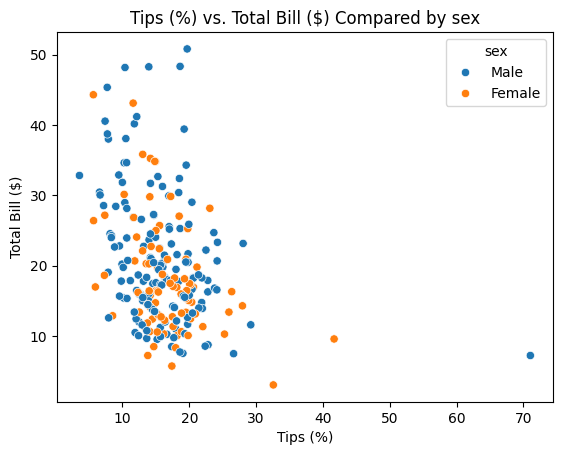

2026-06-07 19:06:49 | INFO | EDA-NBA | Creating scatter plot with hue set to: smoker
2026-06-07 19:06:49 | INFO | EDA-NBA | Saved scatter plot to: ..\docs\images\inflation_NOT_considered\scatter_tips_total_bill_by_smoker.png


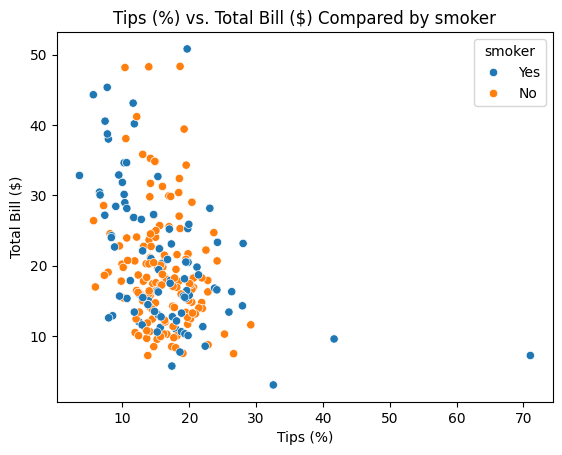

2026-06-07 19:06:49 | INFO | EDA-NBA | Creating scatter plot with hue set to: day
2026-06-07 19:06:50 | INFO | EDA-NBA | Saved scatter plot to: ..\docs\images\inflation_NOT_considered\scatter_tips_total_bill_by_day.png


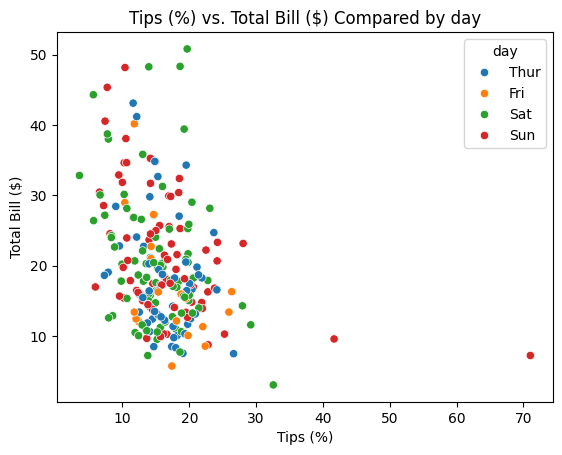

2026-06-07 19:06:50 | INFO | EDA-NBA | Creating scatter plot with hue set to: time
2026-06-07 19:06:50 | INFO | EDA-NBA | Saved scatter plot to: ..\docs\images\inflation_NOT_considered\scatter_tips_total_bill_by_time.png


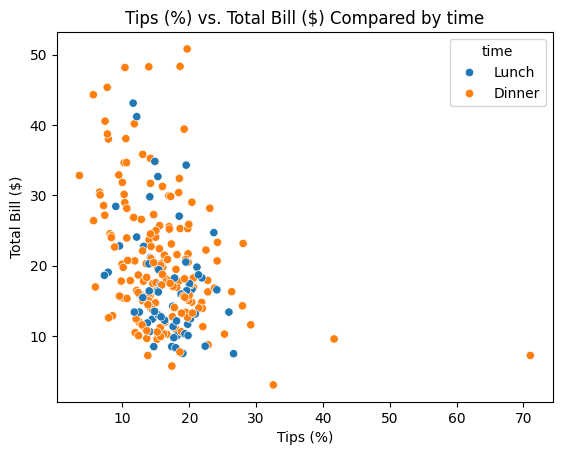

In [27]:
# Loop through other categories and save figures
plt.figure()  # Start a new figure for the next plot
for category in df_clean.select_dtypes(include="category").columns:
    plt.figure()  # Start a new figure for each category
    LOG.info(f"Creating scatter plot with hue set to: {category}")
    scatter_plt: Axes = sns.scatterplot(
        data=df_clean, x="percent_tips", y="total_bill", hue=category
    )
    scatter_plt.set_xlabel("Tips (%)")
    scatter_plt.set_ylabel("Total Bill ($)")
    scatter_plt.set_title(f"Tips (%) vs. Total Bill ($) Compared by {category}")
    scatter_plot_path = OUTPUT_DIR / f"scatter_tips_total_bill_by_{category}.png"
    plt.savefig(scatter_plot_path)
    LOG.info(f"Saved scatter plot to: {scatter_plot_path}")
    plt.show()

### Let's see how often the tip amount made the total cost a clean integer

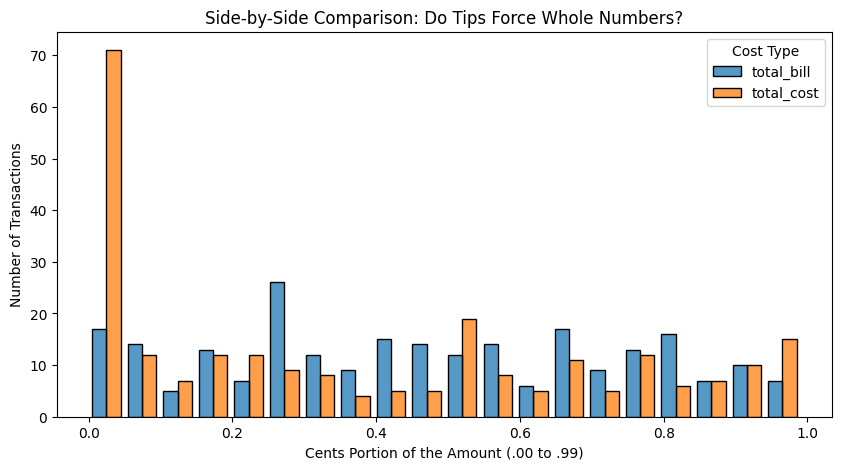

In [28]:
df_melted = pd.melt(
    df_clean,
    value_vars=['total_bill', 'total_cost'],
    var_name='Cost Type',
    value_name='amount',
)
df_melted['cents'] = df_melted['amount'] % 1

# 2. Plot side-by-side bars using specific, targeted bins (0.0 to 1.0)
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_melted, x='cents', hue='Cost Type', multiple='dodge', bins=20, shrink=0.8
)

plt.title("Side-by-Side Comparison: Do Tips Force Whole Numbers?")
plt.xlabel("Cents Portion of the Amount (.00 to .99)")
plt.ylabel("Number of Transactions")
plt.savefig(OUTPUT_DIR / "histogram_whole_number_comparison.png")
if SCALING_FACTOR != 1.0:
    LOG.info(
        "Values were adjusted for inflation and will affect the distribution. Consider this when interpreting the box plot."
    )
    print(
        "Values were adjusted for inflation and will affect the distribution. Consider this when interpreting the box plot."
    )
plt.show()

In [29]:
### Tips do seem to force whole numbers. Let's see if this is a benefit or a disadvantage for servers

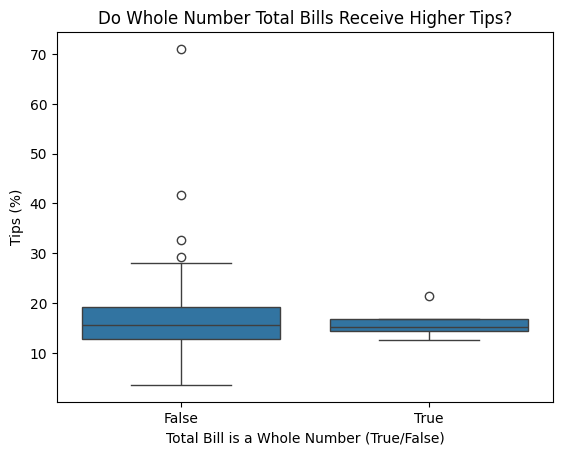

In [30]:
# Compare tip percentages for total bill amounts that are whole numbers vs. those that are not whole numbers
df_clean['total_bill_is_whole'] = df_clean['total_bill'] % 1 == 0
box_plot: Axes = sns.boxplot(data=df_clean, x='total_bill_is_whole', y='percent_tips')
box_plot.set_xlabel("Total Bill is a Whole Number (True/False)")
box_plot.set_ylabel("Tips (%)")
box_plot.set_title("Do Whole Number Total Bills Receive Higher Tips?")
plt.savefig(OUTPUT_DIR / "boxplot_whole_number_tips.png")
if SCALING_FACTOR != 1.0:
    LOG.info(
        "Values were adjusted for inflation and will affect the distribution. Consider this when interpreting the box plot."
    )
    print(
        "Values were adjusted for inflation and will affect the distribution. Consider this when interpreting the box plot."
    )
plt.show()